<a href="https://colab.research.google.com/github/Moali1749/-sma-backtester/blob/main/Backtester_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
def backtest(ticker, window, cost=0.001):
    data = yf.download(ticker, start="2015-01-01", end="2025-01-01", auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    close   = data["Close"]
    returns = close.pct_change()
    sma     = close.rolling(window=window).mean()

    signal   = (close > sma).astype(int)
    position = signal.shift(1)

    trades = position.diff().abs()
    strat  = position * returns - trades * cost

    strat = strat.dropna()
#metriks
    sharpe = (strat.mean() * 252) / (strat.std() * np.sqrt(252))
    equity = (1 + strat).cumprod()
    peak   = equity.cummax()
    max_dd = ((equity - peak) / peak).min()

    n_trades = int(trades.sum())

    return {"sharpe": sharpe, "max_dd": max_dd, "final": equity.iloc[-1], "trades": n_trades}


In [15]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "KO"]
windows = [10, 20, 50, 100, 200]


In [16]:
results = []

for ticker in tickers:
    for window in windows:
        metrics = backtest(ticker, window)
        results.append({
            "ticker": ticker,
            "window": window,
            "sharpe": metrics["sharpe"],
            "max_dd": metrics["max_dd"],
            "final":  metrics["final"]
        })


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [17]:
results_df = pd.DataFrame(results)
results_df


,ticker,window,sharpe,max_dd,final
0,AAPL,10,0.667829,-0.392026,2.896234
1,AAPL,20,1.333393,-0.240849,9.900416
2,AAPL,50,0.767399,-0.308849,3.609026
3,AAPL,100,0.673265,-0.303818,3.188332
4,AAPL,200,0.796497,-0.358320,4.659880
5,MSFT,10,0.184650,-0.343251,1.185536
6,MSFT,20,0.251232,-0.437601,1.338589
7,MSFT,50,0.458354,-0.370784,1.994924
8,MSFT,100,0.560568,-0.370870,2.574193
9,MSFT,200,0.774931,-0.405333,4.338415


In [18]:
sharpe_grid = results_df.pivot(index="ticker", columns="window", values="sharpe")
sharpe_grid


window,10,20,50,100,200
ticker,,,,,
AAPL,0.667829,1.333393,0.767399,0.673265,0.796497
AMZN,0.604559,0.734413,0.796565,0.655042,0.614409
GOOGL,-0.112542,0.356185,0.385532,0.579915,0.610608
KO,-0.152018,-0.146509,0.106423,0.290600,0.267244
MSFT,0.184650,0.251232,0.458354,0.560568,0.774931


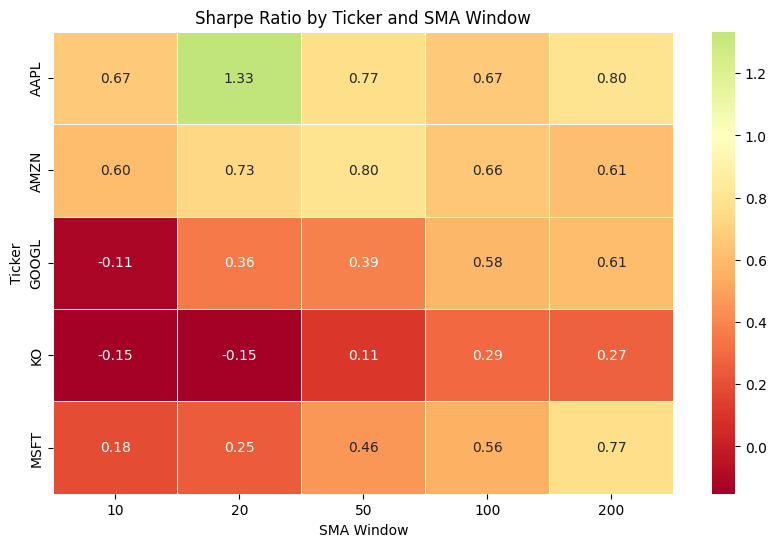

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(sharpe_grid,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=1.0,
            linewidths=0.5)
plt.title("Sharpe Ratio by Ticker and SMA Window")
plt.xlabel("SMA Window")
plt.ylabel("Ticker")
plt.show()
